<a href="https://colab.research.google.com/github/navjotkaur0125/CS5720-home-assignment-3/blob/main/CS5720-Assignment-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.11.0+cpu
CUDA Available: False


In [10]:
# QUESTION 1: Implement 2D Convolution from Scratch
# The full 5x5 input matrix from Home Assignment 3:
input_matrix = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 4, 1],
    [3, 0, 1, 2, 0],
    [1, 2, 0, 1, 2],
    [0, 1, 3, 1, 0]
], dtype=float)

# The 3x3 filter kernel:
kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
], dtype=float)

def convolve2d(image, filter_kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    H_in, W_in = image.shape
    K_h, K_w = filter_kernel.shape

    # Calculate output dimensions: N_out = (N - F + 2P) / S + 1
    H_out = (H_in - K_h) // stride + 1
    W_out = (W_in - K_w) // stride + 1

    output = np.zeros((H_out, W_out))

    # b & c. Slide filter over input matrix and compute dot product sum at every valid location
    for i in range(H_out):
        for j in range(W_out):
            region = image[i*stride : i*stride + K_h, j*stride : j*stride + K_w]
            output[i, j] = np.sum(region * filter_kernel)

    return output

# d & e. Stride = 1 Convolution
output_stride1 = convolve2d(input_matrix, kernel, stride=1, padding=0)
print("=== Output Feature Map (Stride = 1, Padding = 0) ===")
print(output_stride1)
print("\nOutput Shape (Stride = 1):", output_stride1.shape)

# f. Stride = 2 Convolution
output_stride2 = convolve2d(input_matrix, kernel, stride=2, padding=0)
print("\n=== Output Feature Map (Stride = 2, Padding = 0) ===")
print(output_stride2)
print("\nOutput Shape (Stride = 2):", output_stride2.shape)

=== Output Feature Map (Stride = 1, Padding = 0) ===
[[9. 6. 9.]
 [3. 9. 7.]
 [9. 4. 5.]]

Output Shape (Stride = 1): (3, 3)

=== Output Feature Map (Stride = 2, Padding = 0) ===
[[9. 9.]
 [9. 5.]]

Output Shape (Stride = 2): (2, 2)


In [6]:
# QUESTION 2: Transfer Learning (Dataset & DataLoader Setup)

import time
import torch
import torch.nn as nn
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Preprocessing pipeline required for ImageNet-pretrained models
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Filter CIFAR-10 for a 2-class classification task (0: Airplane, 1: Automobile)
def get_binary_cifar10(train=True, transform=None):
    dataset = datasets.CIFAR10(root='./data', train=train, download=True, transform=transform)
    # FIXED: Filter for both class 0 (Airplane) and class 1 (Automobile)
    indices = [i for i, label in enumerate(dataset.targets) if label in [0, 1]]
    sub_dataset = torch.utils.data.Subset(dataset, indices)
    return sub_dataset

train_dataset = get_binary_cifar10(train=True, transform=data_transforms['train'])
val_dataset = get_binary_cifar10(train=False, transform=data_transforms['val'])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, criterion, optimizer, num_epochs=5):
    start_time = time.time()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_dataset)
        history['train_loss'].append(epoch_train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        corrects = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(val_dataset)
        epoch_val_acc = (corrects.double() / len(val_dataset)).item()
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

    total_time = time.time() - start_time
    return history, total_time

Using device: cuda


100%|██████████| 170M/170M [10:24<00:00, 273kB/s]


In [7]:
# EXPERIMENT A: Frozen Feature Extractor

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("--- EXPERIMENT A: Frozen Feature Extractor ---")
print(f"Using device: {device}")

# Helper function to count parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_a = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all feature extraction backbone layers
for param in model_a.parameters():
    param.requires_grad = False

# Replace output layer (2 classes)
num_ftrs = model_a.fc.in_features
model_a.fc = nn.Linear(num_ftrs, 2)
model_a = model_a.to(device)

params_a = count_trainable_parameters(model_a)
print(f"Trainable Parameters (Experiment A): {params_a:,}")

criterion = nn.CrossEntropyLoss()
optimizer_a = optim.Adam(model_a.fc.parameters(), lr=0.001)

history_a, time_a = train_model(model_a, criterion, optimizer_a, num_epochs=5)

--- EXPERIMENT A: Frozen Feature Extractor ---
Using device: cuda
Trainable Parameters (Experiment A): 1,026
Epoch 1/5 | Train Loss: 0.2386 | Val Loss: 0.1211 | Val Acc: 96.80%
Epoch 2/5 | Train Loss: 0.1349 | Val Loss: 0.0988 | Val Acc: 96.80%
Epoch 3/5 | Train Loss: 0.1202 | Val Loss: 0.0889 | Val Acc: 96.95%
Epoch 4/5 | Train Loss: 0.1104 | Val Loss: 0.0829 | Val Acc: 97.00%
Epoch 5/5 | Train Loss: 0.1042 | Val Loss: 0.0840 | Val Acc: 96.95%



--- EXPERIMENT B: Fine-Tuned Network ---
Trainable Parameters (Experiment B): 8,394,754
Epoch 1/5 | Train Loss: 0.0739 | Val Loss: 0.0371 | Val Acc: 98.90%
Epoch 2/5 | Train Loss: 0.0243 | Val Loss: 0.0332 | Val Acc: 98.95%
Epoch 3/5 | Train Loss: 0.0127 | Val Loss: 0.0306 | Val Acc: 98.90%
Epoch 4/5 | Train Loss: 0.0118 | Val Loss: 0.0249 | Val Acc: 98.95%
Epoch 5/5 | Train Loss: 0.0078 | Val Loss: 0.0397 | Val Acc: 99.15%


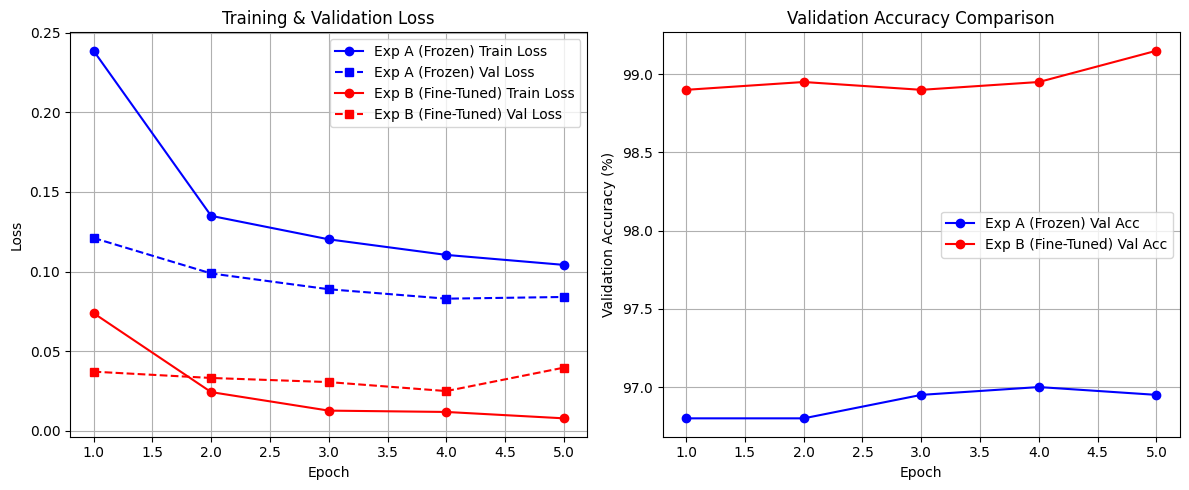


Method                       | Trainable Params | Time (s) | Final Val Acc
-----------------------------------------------------------------
Exp A (Frozen Base)          | 1,026            | 117.74   | 96.95      %
Exp B (Fine-Tuned layer4)    | 8,394,754        | 120.62   | 99.15      %


In [10]:
# EXPERIMENT B: Fine-Tuned Network

print("\n--- EXPERIMENT B: Fine-Tuned Network ---")

model_b = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze base layers initially
for param in model_b.parameters():
    param.requires_grad = False

# Unfreeze late convolutional block (layer4) for fine-tuning
for param in model_b.layer4.parameters():
    param.requires_grad = True

model_b.fc = nn.Linear(num_ftrs, 2)
model_b = model_b.to(device)

params_b = count_trainable_parameters(model_b)
print(f"Trainable Parameters (Experiment B): {params_b:,}")

# Differential learning rates: smaller LR for pretrained backbone block
optimizer_b = optim.Adam([
    {'params': model_b.layer4.parameters(), 'lr': 0.0001},
    {'params': model_b.fc.parameters(), 'lr': 0.001}
])

history_b, time_b = train_model(model_b, criterion, optimizer_b, num_epochs=5)

# Cell 6: Visualizations & Summary Table
# Plot Training Curves and Output Results Summary
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 6), history_a['train_loss'], 'b-o', label='Exp A (Frozen) Train Loss')
plt.plot(range(1, 6), history_a['val_loss'], 'b--s', label='Exp A (Frozen) Val Loss')
plt.plot(range(1, 6), history_b['train_loss'], 'r-o', label='Exp B (Fine-Tuned) Train Loss')
plt.plot(range(1, 6), history_b['val_loss'], 'r--s', label='Exp B (Fine-Tuned) Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 6), [acc * 100 for acc in history_a['val_acc']], 'b-o', label='Exp A (Frozen) Val Acc')
plt.plot(range(1, 6), [acc * 100 for acc in history_b['val_acc']], 'r-o', label='Exp B (Fine-Tuned) Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('transfer_learning_comparison.png')
plt.show()

# Print Comparison Summary Table
print("\n" + "="*65)
print(f"{'Method':<28} | {'Trainable Params':<16} | {'Time (s)':<8} | {'Final Val Acc':<12}")
print("-"*65)
print(f"{'Exp A (Frozen Base)':<28} | {params_a:<16,} | {time_a:<8.2f} | {history_a['val_acc'][-1]*100:<11.2f}%")
print(f"{'Exp B (Fine-Tuned layer4)':<28} | {params_b:<16,} | {time_b:<8.2f} | {history_b['val_acc'][-1]*100:<11.2f}%")
print("="*65)